In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
path = "loan_data.csv"

df = pd.read_csv(path)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
print("HEAD:")
print(df.head())
print("\n\nTAIL:")
print(df.tail())

HEAD:
   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status  
0                 17600000             22700000       

In [6]:
rows, columns = df.shape

print("Rows :", rows)
print("Columns :", columns)

Rows : 4269
Columns : 13


In [7]:
print(df.columns)



Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [8]:
print(df.dtypes)

loan_id                     int64
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 383.6 KB


In [10]:
print(df.describe())

           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    20.000000   

       cibil_score  residential_assets_value  commercial_assets_value  \
count  4269.000000              4.269000e+03             4.269000e+03   
mean    599.936051              7.472617e+06             4.973155e+06   
std     172.430401              6.503637e+06       

In [11]:
print(df.isnull().sum())

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [12]:
duplicates = df.duplicated().sum()

print("Duplicate rows :", duplicates)

df = df.drop_duplicates()

Duplicate rows : 0


In [13]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns")
print(numerical_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numerical Columns
Index(['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='str')

Categorical Columns
Index(['education', 'self_employed', 'loan_status'], dtype='str')


In [14]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].mean())

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values handled.")

Missing values handled.


In [15]:
encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Categorical columns encoded.")

Categorical columns encoded.


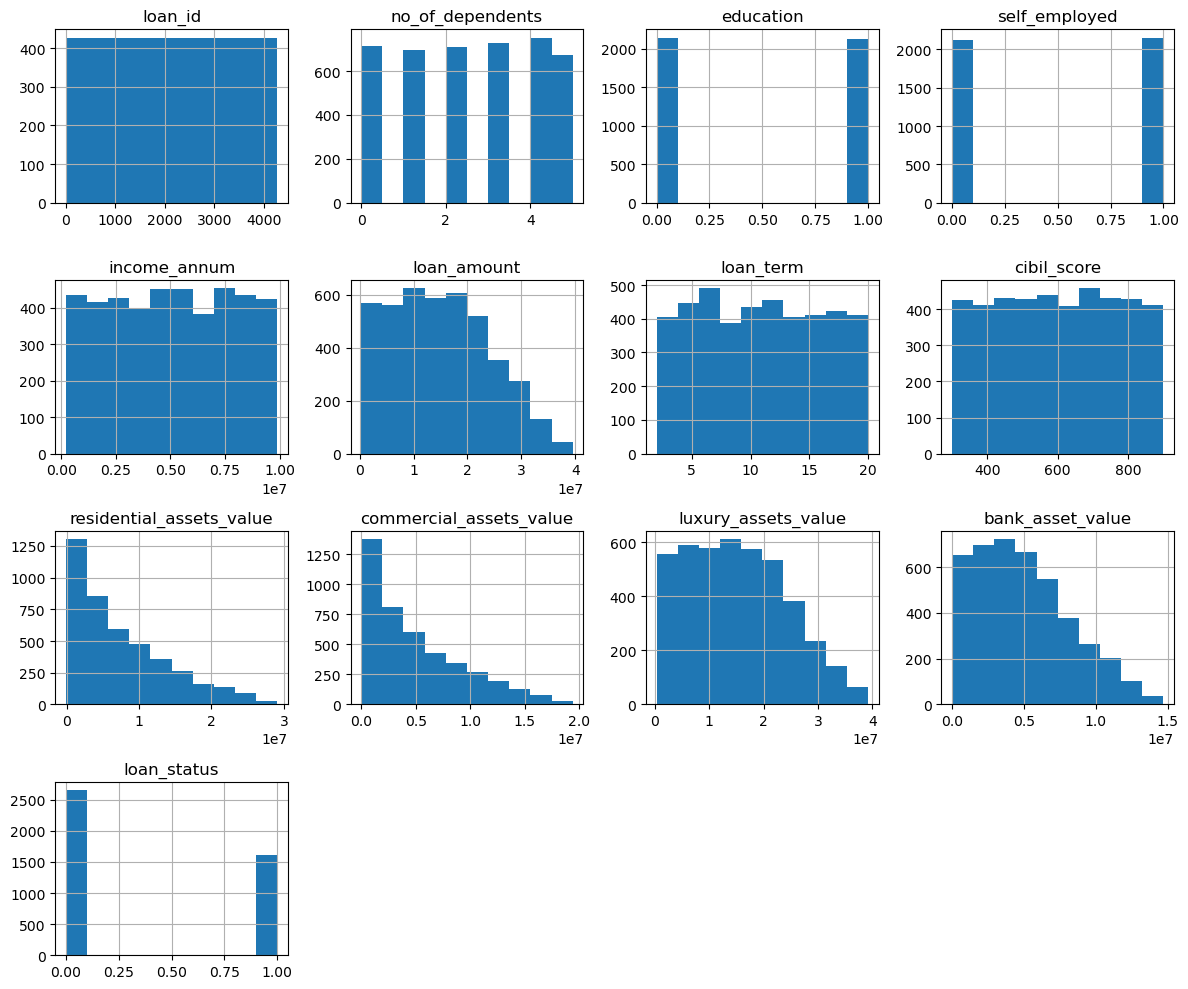

In [16]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

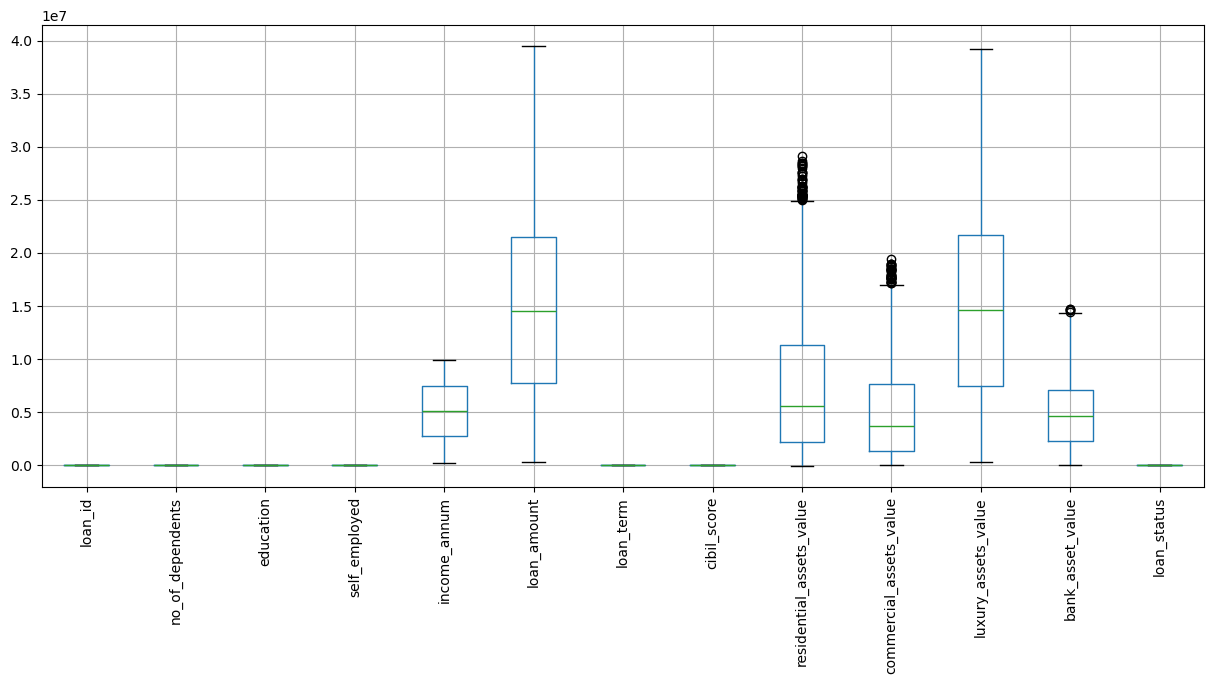

In [17]:
df.boxplot(figsize=(15,6), rot=90)

plt.show()

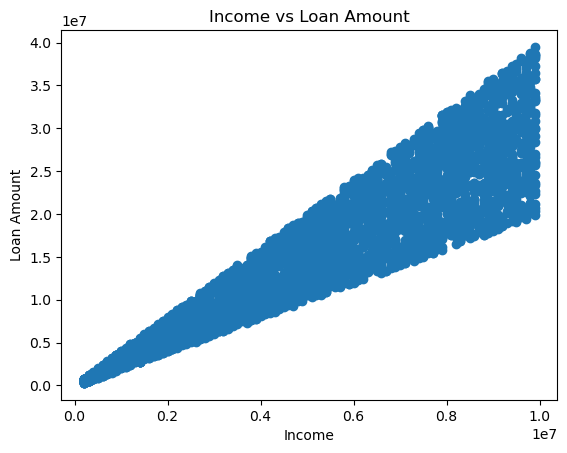

In [18]:
plt.scatter(df["income_annum"], df["loan_amount"])

plt.xlabel("Income")

plt.ylabel("Loan Amount")

plt.title("Income vs Loan Amount")

plt.show()

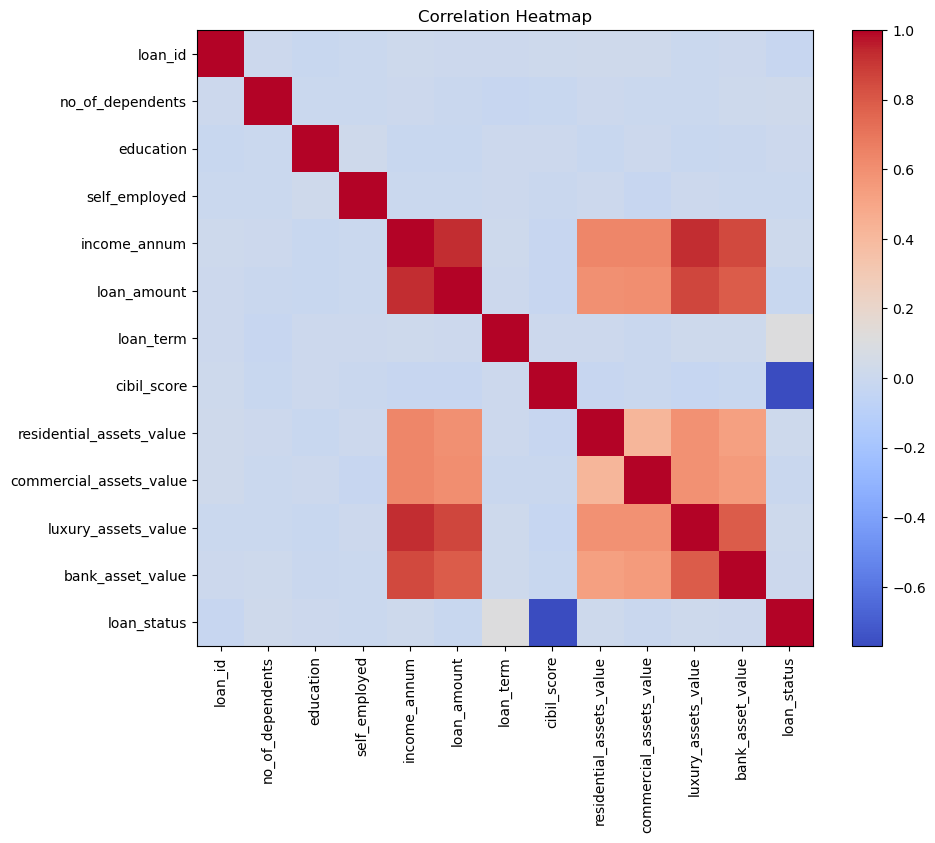

In [19]:
corr = df.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[numerical_columns])

print(scaled_data[:5])

[[-1.73164513 -0.2941017   1.61797904  1.63305171  0.19261651  1.03279241
  -0.78005754  2.877289    0.83202837  0.93030441]
 [-1.73083367 -1.4735476  -0.34174956 -0.32441406 -0.50809068 -1.06105118
  -0.7339241  -0.63192107 -0.69499321 -0.51593638]
 [-1.73002222  0.29562125  1.4398219   1.61093345  1.59403089 -0.54484044
  -0.05730028 -0.10781827  1.99651964  2.40731629]
 [-1.72921076  0.29562125  1.11913903  1.72152474 -0.50809068 -0.77104514
   1.64963709 -0.38126321  0.89794297  0.89953333]
 [-1.72839931  1.47506715  1.6892419   1.00268138  1.59403089 -1.26405541
   0.75772387  0.73530363  1.56807474  0.00717199]]


In [21]:
normalizer = MinMaxScaler()

normalized_data = normalizer.fit_transform(df[numerical_columns])

print(normalized_data[:5])

[[0.00000000e+00 4.00000000e-01 9.69072165e-01 7.55102041e-01
  5.55555556e-01 7.96666667e-01 8.56164384e-02 9.07216495e-01
  5.75835476e-01 5.44217687e-01]
 [2.34301781e-04 0.00000000e+00 4.02061856e-01 3.03571429e-01
  3.33333333e-01 1.95000000e-01 9.58904110e-02 1.13402062e-01
  2.18508997e-01 2.24489796e-01]
 [4.68603561e-04 6.00000000e-01 9.17525773e-01 7.50000000e-01
  1.00000000e+00 3.43333333e-01 2.46575342e-01 2.31958763e-01
  8.48329049e-01 8.70748299e-01]
 [7.02905342e-04 6.00000000e-01 8.24742268e-01 7.75510204e-01
  3.33333333e-01 2.78333333e-01 6.26712329e-01 1.70103093e-01
  5.91259640e-01 5.37414966e-01]
 [9.37207123e-04 1.00000000e+00 9.89690722e-01 6.09693878e-01
  1.00000000e+00 1.36666667e-01 4.28082192e-01 4.22680412e-01
  7.48071979e-01 3.40136054e-01]]
